(640, 480)


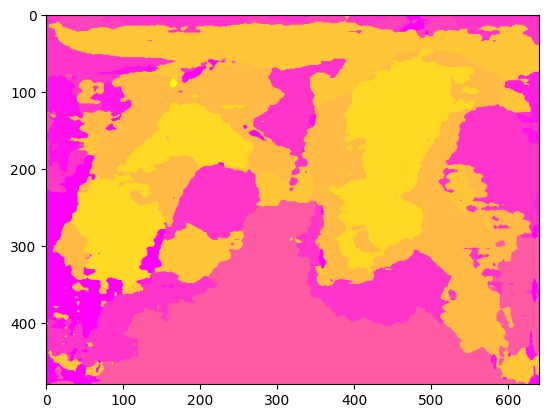

In [4]:
from transformers import AutoImageProcessor, BeitForSemanticSegmentation
from PIL import Image
import httpx
from io import BytesIO
import torch.nn as nn

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
with httpx.stream("GET", url) as response:
    image = Image.open(BytesIO(response.read()))
    print(image.size)  # W, H
    
image_processor = AutoImageProcessor.from_pretrained("H:/00models/beit-base-finetuned-ade-640-640")
model = BeitForSemanticSegmentation.from_pretrained("H:/00models/beit-base-finetuned-ade-640-640")

inputs = image_processor(images=image, return_tensors="pt")
outputs = model(**inputs)
# logits are of shape (batch_size, num_labels, height, width)
logits = outputs.logits

# -------------------------------------------------------------
# 缩放
results = nn.functional.interpolate(logits,   # 插值缩放
                size=image.size[::-1], # 逆序：W x H -> H x W
                mode='bilinear',
                align_corners=False)
# 处理分类
labels = results.argmax(dim=1)[0].cpu().numpy()
# labels, probs = results.max(dim=1)
# 可视化
import matplotlib.pyplot as plt

plt.imshow(labels, cmap="spring") 
plt.show()

- 分隔算法：
    - YOLO
    - CNN
    - SSD
    - DeepSort